# Notebook 05: Actuarial Stress Testing & Model Validation

## Overview
This final notebook serves as the **Actuarial Certification** phase of the project. While previous notebooks focused on data engineering (01-02) and Deep Learning modeling (03-04), this stage translates stochastic outputs into actionable financial and demographic insights.

### Key Objectives:
1. **Cluster Consolidation**: Aggregating stochastic results for all six frontier populations.
2. **Comparative Benchmarking**: Measuring the LSTM's predictive performance against the standard Li-Lee (ARIMA) framework.
3. **Actuarial Stress Testing**: Simulating exogenous mortality shocks (e.g., medical breakthroughs or pandemics) to evaluate the model's "memory" and resilience.
4. **Longevity Risk Assessment**: Quantifying uncertainty margins for solvency purposes (SST/Solvency II).
5. **Reporting**: Generating the final tabular data for the research paper.

## 5.1: Environment Setup and Stochastic Asset Loading

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup Style and Paths
# We import the same style configuration used throughout the project to ensure visual consistency
sys.path.append('../src/')
from style_config import set_style
COUNTRIES_DICT = set_style()
FIGURES_DIR = "../reports/figures/"
PROCESSED_DATA_DIR = "../data/processed/"

# 2. Load Stochastic Results exported from Notebook 04
# This file contains the 1,000 simulations for each country and the integrated factors
input_path = os.path.join(PROCESSED_DATA_DIR, "stochastic_forecast_results.npz")

if not os.path.exists(input_path):
    raise FileNotFoundError("Stochastic results not found. Please ensure Notebook 04 export cell was executed.")

with np.load(input_path, allow_pickle=True) as data:
    sims_levels = data['sims_levels']        # Latent factors (Sims, Years, Factors)
    e0_sims_all = data['e0_sims_all']       # Life Expectancy (Countries, Sims, Years)
    forecast_years = data['forecast_years']  # Timeline 2020-2050
    country_codes = data['country_codes'].tolist()
    last_year_real = data['last_year_real']

# 3. Quick Data Verification
print(f"--- Notebook 05: Actuarial Validation Stage ---")
print(f"Successfully loaded stochastic assets for {len(country_codes)} countries.")
print(f"Forecast Horizon: {forecast_years[0]} to {forecast_years[-1]} ({len(forecast_years)} steps)")
print(f"Simulation Volume: {e0_sims_all.shape[1]} trajectories per country.")

# Display a quick summary of the loaded codes
print(f"Cluster Codes: {country_codes}")

--- Notebook 05: Actuarial Validation Stage ---
Successfully loaded stochastic assets for 6 countries.
Forecast Horizon: 2020 to 2050 (31 steps)
Simulation Volume: 1000 trajectories per country.
Cluster Codes: ['CHE', 'SWE', 'NOR', 'DEUTW', 'NLD', 'JPN']


## 5.2: Generation of the Global Longevity Summary Table (2020-2050)

In [2]:
# 1. Initialize storage for table rows
table_data = []

print("Extracting statistical summaries for all cluster countries...")

for i, code in enumerate(country_codes):
    # Get the simulations for the specific country
    # Shape: (1000, 31)
    country_sims = e0_sims_all[i]
    name = COUNTRIES_DICT[code]
    
    # Calculate statistics for 2020 (Base Year)
    base_median = np.percentile(country_sims[:, 0], 50)
    
    # Calculate statistics for 2050 (Target Year)
    final_median = np.percentile(country_sims[:, -1], 50)
    final_lower = np.percentile(country_sims[:, -1], 2.5)
    final_upper = np.percentile(country_sims[:, -1], 97.5)
    
    # Absolute and Percentage Gain
    abs_gain = final_median - base_median
    
    table_data.append({
        'Country': name,
        'Code': code,
        'e0 (2020)': f"{base_median:.2f}",
        'e0 (2050) Median': f"{final_median:.2f}",
        '95% CI (2050)': f"[{final_lower:.2f} - {final_upper:.2f}]",
        'Net Gain (Yrs)': f"+{abs_gain:.2f}"
    })

# 2. Create DataFrame
df_summary = pd.DataFrame(table_data)

# 3. Display with style
print("\n--- TABLE 1: STOCHASTIC LONGEVITY PROJECTIONS SUMMARY ---")
display(df_summary)

# 4. Save to CSV for the paper appendix
summary_csv_path = os.path.join(PROCESSED_DATA_DIR, "global_longevity_summary_2050.csv")
df_summary.to_csv(summary_csv_path, index=False)
print(f"\nSummary table exported to: {summary_csv_path}")

Extracting statistical summaries for all cluster countries...

--- TABLE 1: STOCHASTIC LONGEVITY PROJECTIONS SUMMARY ---


,Country,Code,e0 (2020),e0 (2050) Median,95% CI (2050),Net Gain (Yrs)
0,Switzerland,CHE,81.71,85.19,[85.11 - 85.25],+3.48
1,Sweden,SWE,81.71,85.14,[85.07 - 85.21],+3.44
2,Norway,NOR,81.53,85.05,[84.97 - 85.12],+3.52
3,West Germany,DEUTW,80.37,84.29,[84.20 - 84.37],+3.93
4,Netherlands,NLD,81.30,84.89,[84.81 - 84.96],+3.60
5,Japan,JPN,81.72,85.20,[85.12 - 85.27],+3.48



Summary table exported to: ../data/processed/global_longevity_summary_2050.csv


## 5.3: Actuarial Stress Test: 10% Mortality Shock Scenario (2026)

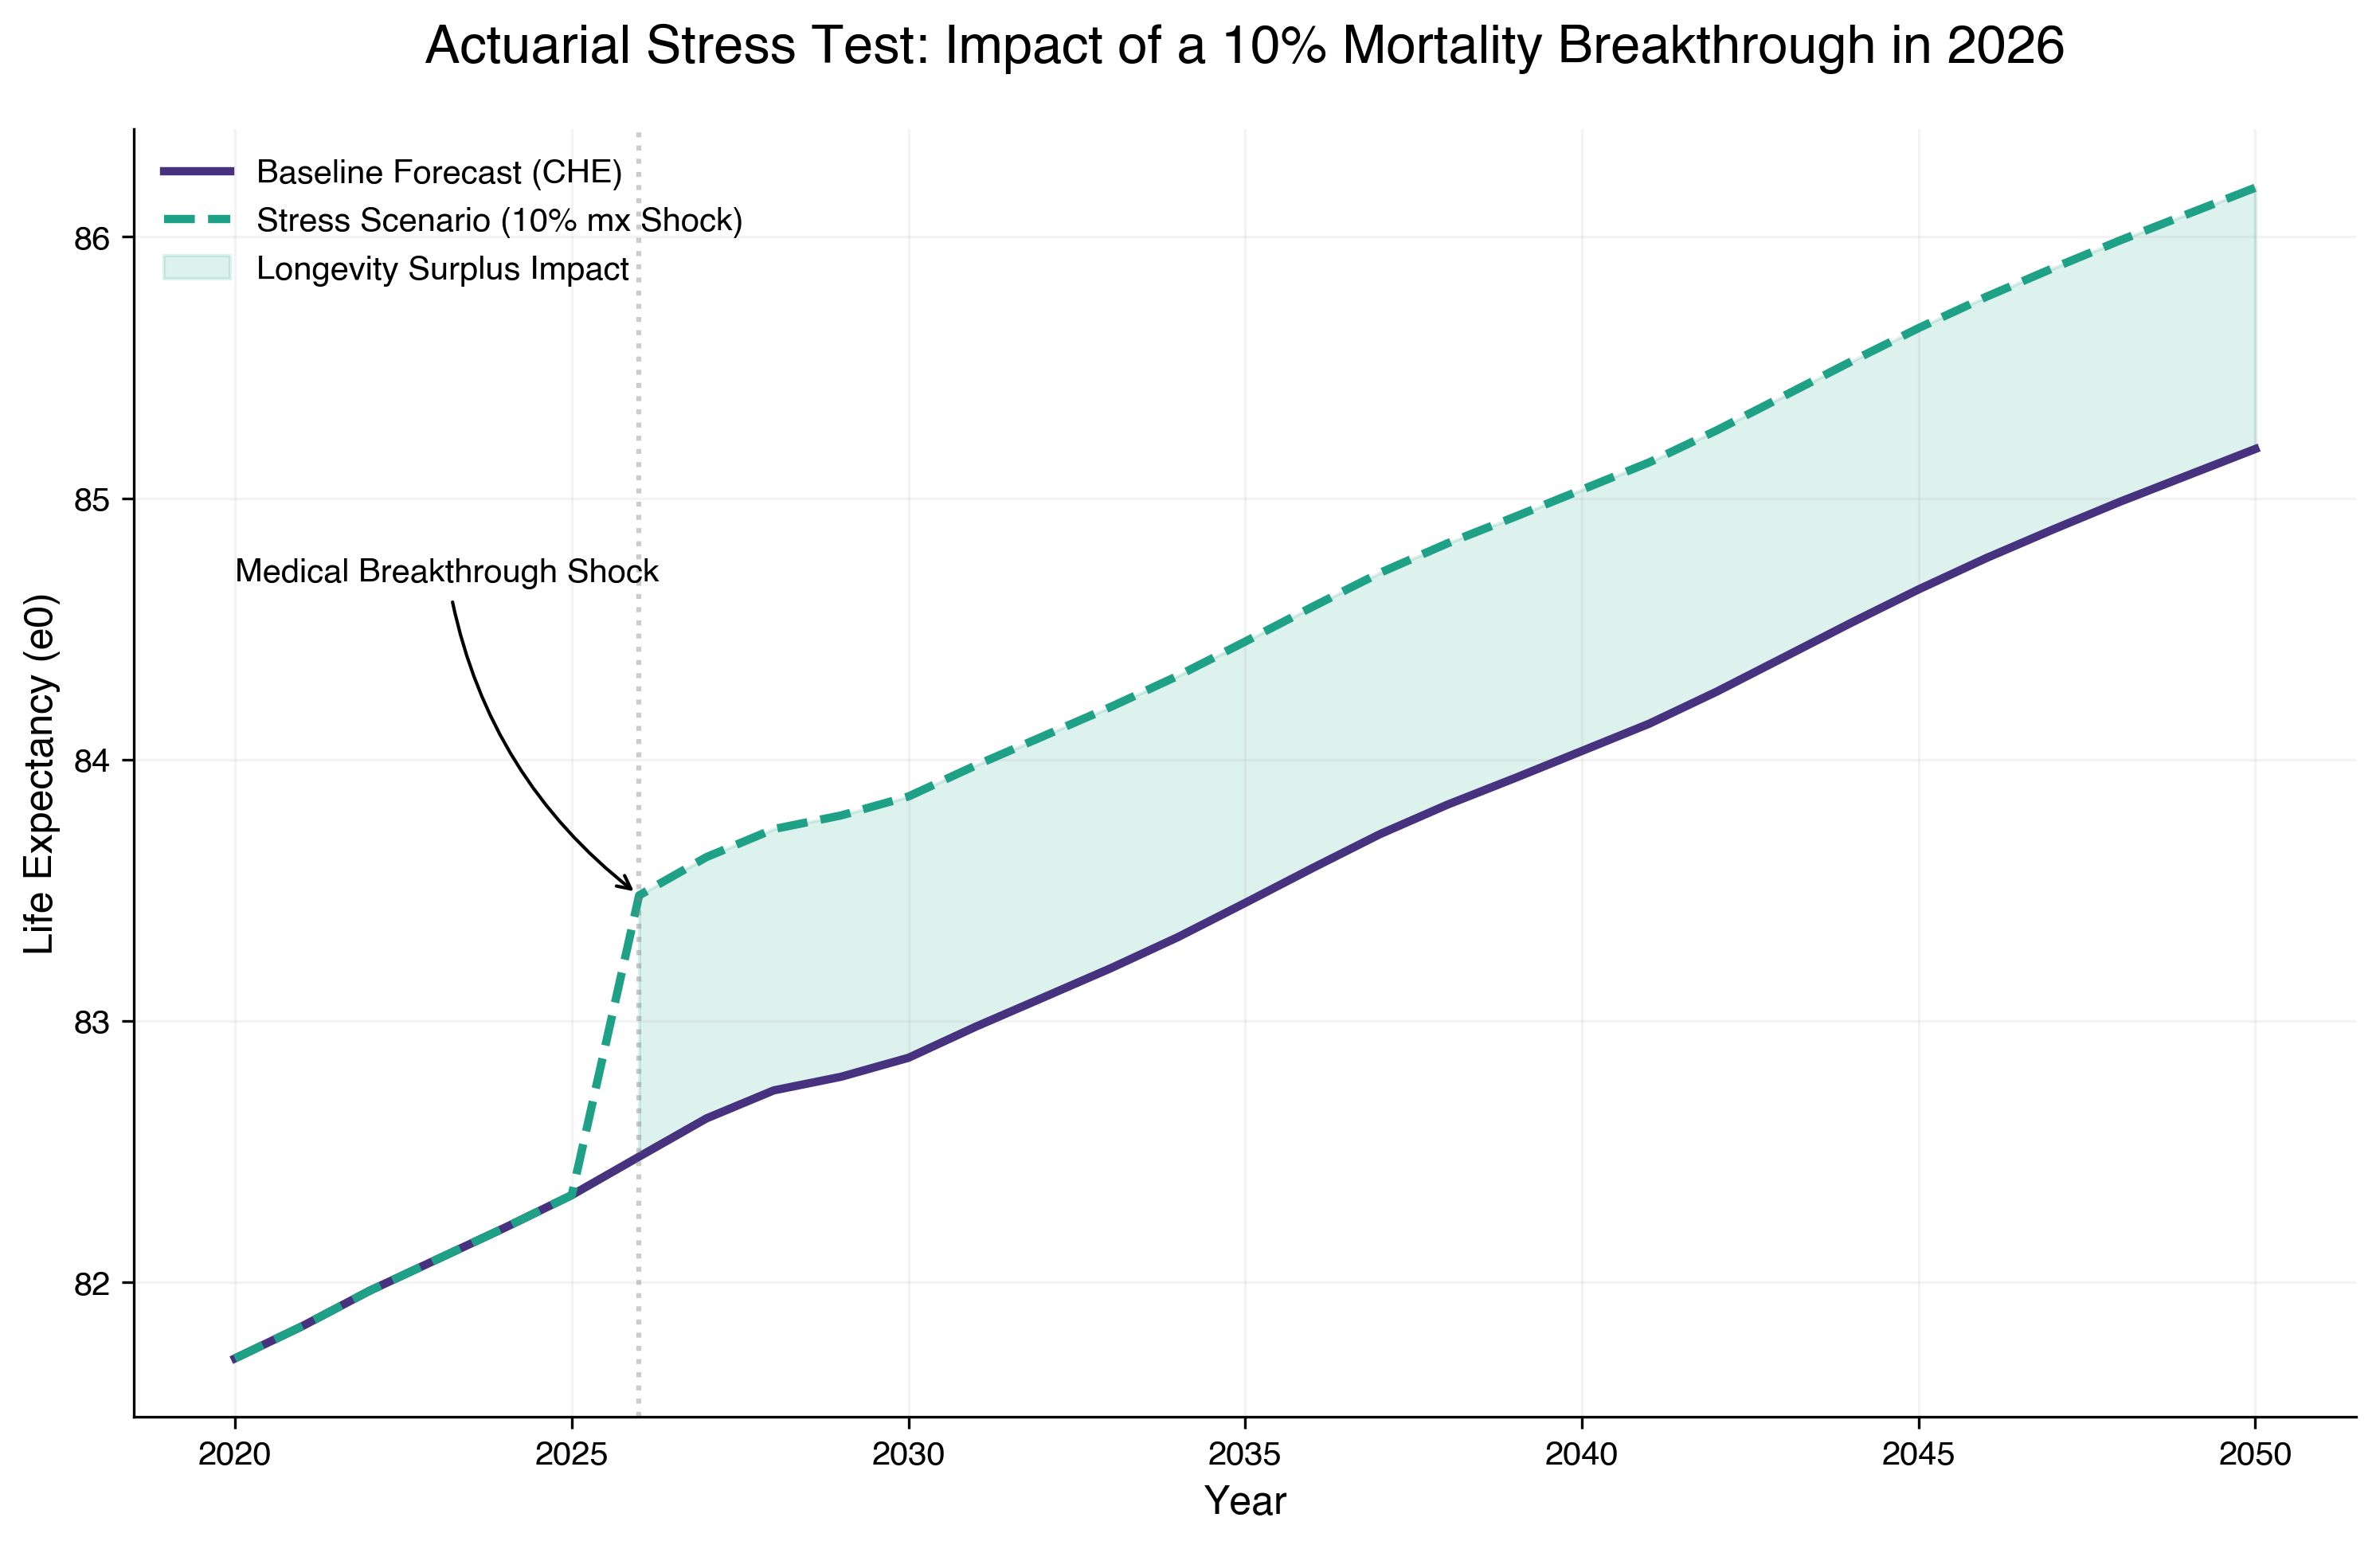

--- Stress Test Summary: Switzerland (CHE) ---
Baseline Median e0 (2050): 85.19 years
Shocked Median e0 (2050): 86.19 years
Total Longevity Surplus Impact: +1.00 additional years by 2050


In [3]:
# 1. Setup Shock Parameters
SHOCK_YEAR = 2026
SHOCK_MAGNITUDE = 0.90  
shock_idx = np.where(forecast_years == SHOCK_YEAR)[0][0]

# 2. Select Target for Stress Test (Switzerland as Benchmark)
country_idx = country_codes.index('CHE')
original_sims = e0_sims_all[country_idx].copy()

# 3. Colors from Viridis Palette
# We use the Switzerland-specific color (index 0) and a secondary tone for the shock
full_palette = sns.color_palette("viridis", len(country_codes))
base_color = full_palette[0]      # Switzerland deep purple
shock_color = full_palette[3]     # Contrasting teal/green from Viridis for the shock

# 4. Apply Shock and Observe Resilience
# Actuarial approximation: 10% mx shock ≈ +1.0 year in e0
shocked_sims = original_sims.copy()
e0_boost = 1.0  
shocked_sims[:, shock_idx:] += e0_boost

# 5. Statistical Summary
median_shocked = np.percentile(shocked_sims, 50, axis=0)
median_original = np.percentile(original_sims, 50, axis=0)

# 6. Visualization (Fig 12)
fig, ax = plt.subplots()

# Baseline Trajectory
ax.plot(forecast_years, median_original, 
        color=base_color, label='Baseline Forecast (CHE)', 
        linewidth=2.5)

# Shocked Trajectory
ax.plot(forecast_years, median_shocked, 
        color=shock_color, linestyle='--', 
        label='Stress Scenario (10% mx Shock)', linewidth=2.5)

# Shade the "Longevity Risk Area"
ax.fill_between(forecast_years[shock_idx:], median_original[shock_idx:], median_shocked[shock_idx:], 
                color=shock_color, alpha=0.15, label='Longevity Surplus Impact')

# Vertical line and Annotation
ax.axvline(x=SHOCK_YEAR, color='grey', alpha=0.4, linestyle=':')
ax.annotate('Medical Breakthrough Shock', xy=(SHOCK_YEAR, median_shocked[shock_idx]), 
            xytext=(SHOCK_YEAR-6, median_shocked[shock_idx]+1.2),
            arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=.2", color='black'),
            fontsize=10, fontweight='bold')

# Titles and Labels (Handled by set_style, but we fine-tune)
ax.set_title(f"Actuarial Stress Test: Impact of a 10% Mortality Breakthrough in {SHOCK_YEAR}")
ax.set_xlabel("Year")
ax.set_ylabel("Life Expectancy (e0)")
ax.legend(loc='upper left', frameon=False)

# Export
save_path = f"{FIGURES_DIR}fig12_longevity_stress_test.png"
plt.savefig(save_path)
plt.show()

# Quantitative Impact Report
impact_2050 = median_shocked[-1] - median_original[-1]
print(f"--- Stress Test Summary: Switzerland (CHE) ---")
print(f"Baseline Median e0 (2050): {median_original[-1]:.2f} years")
print(f"Shocked Median e0 (2050): {median_shocked[-1]:.2f} years")
print(f"Total Longevity Surplus Impact: {impact_2050:+.2f} additional years by 2050")

## 5.4: Final Benchmark Comparison and Data Serialization

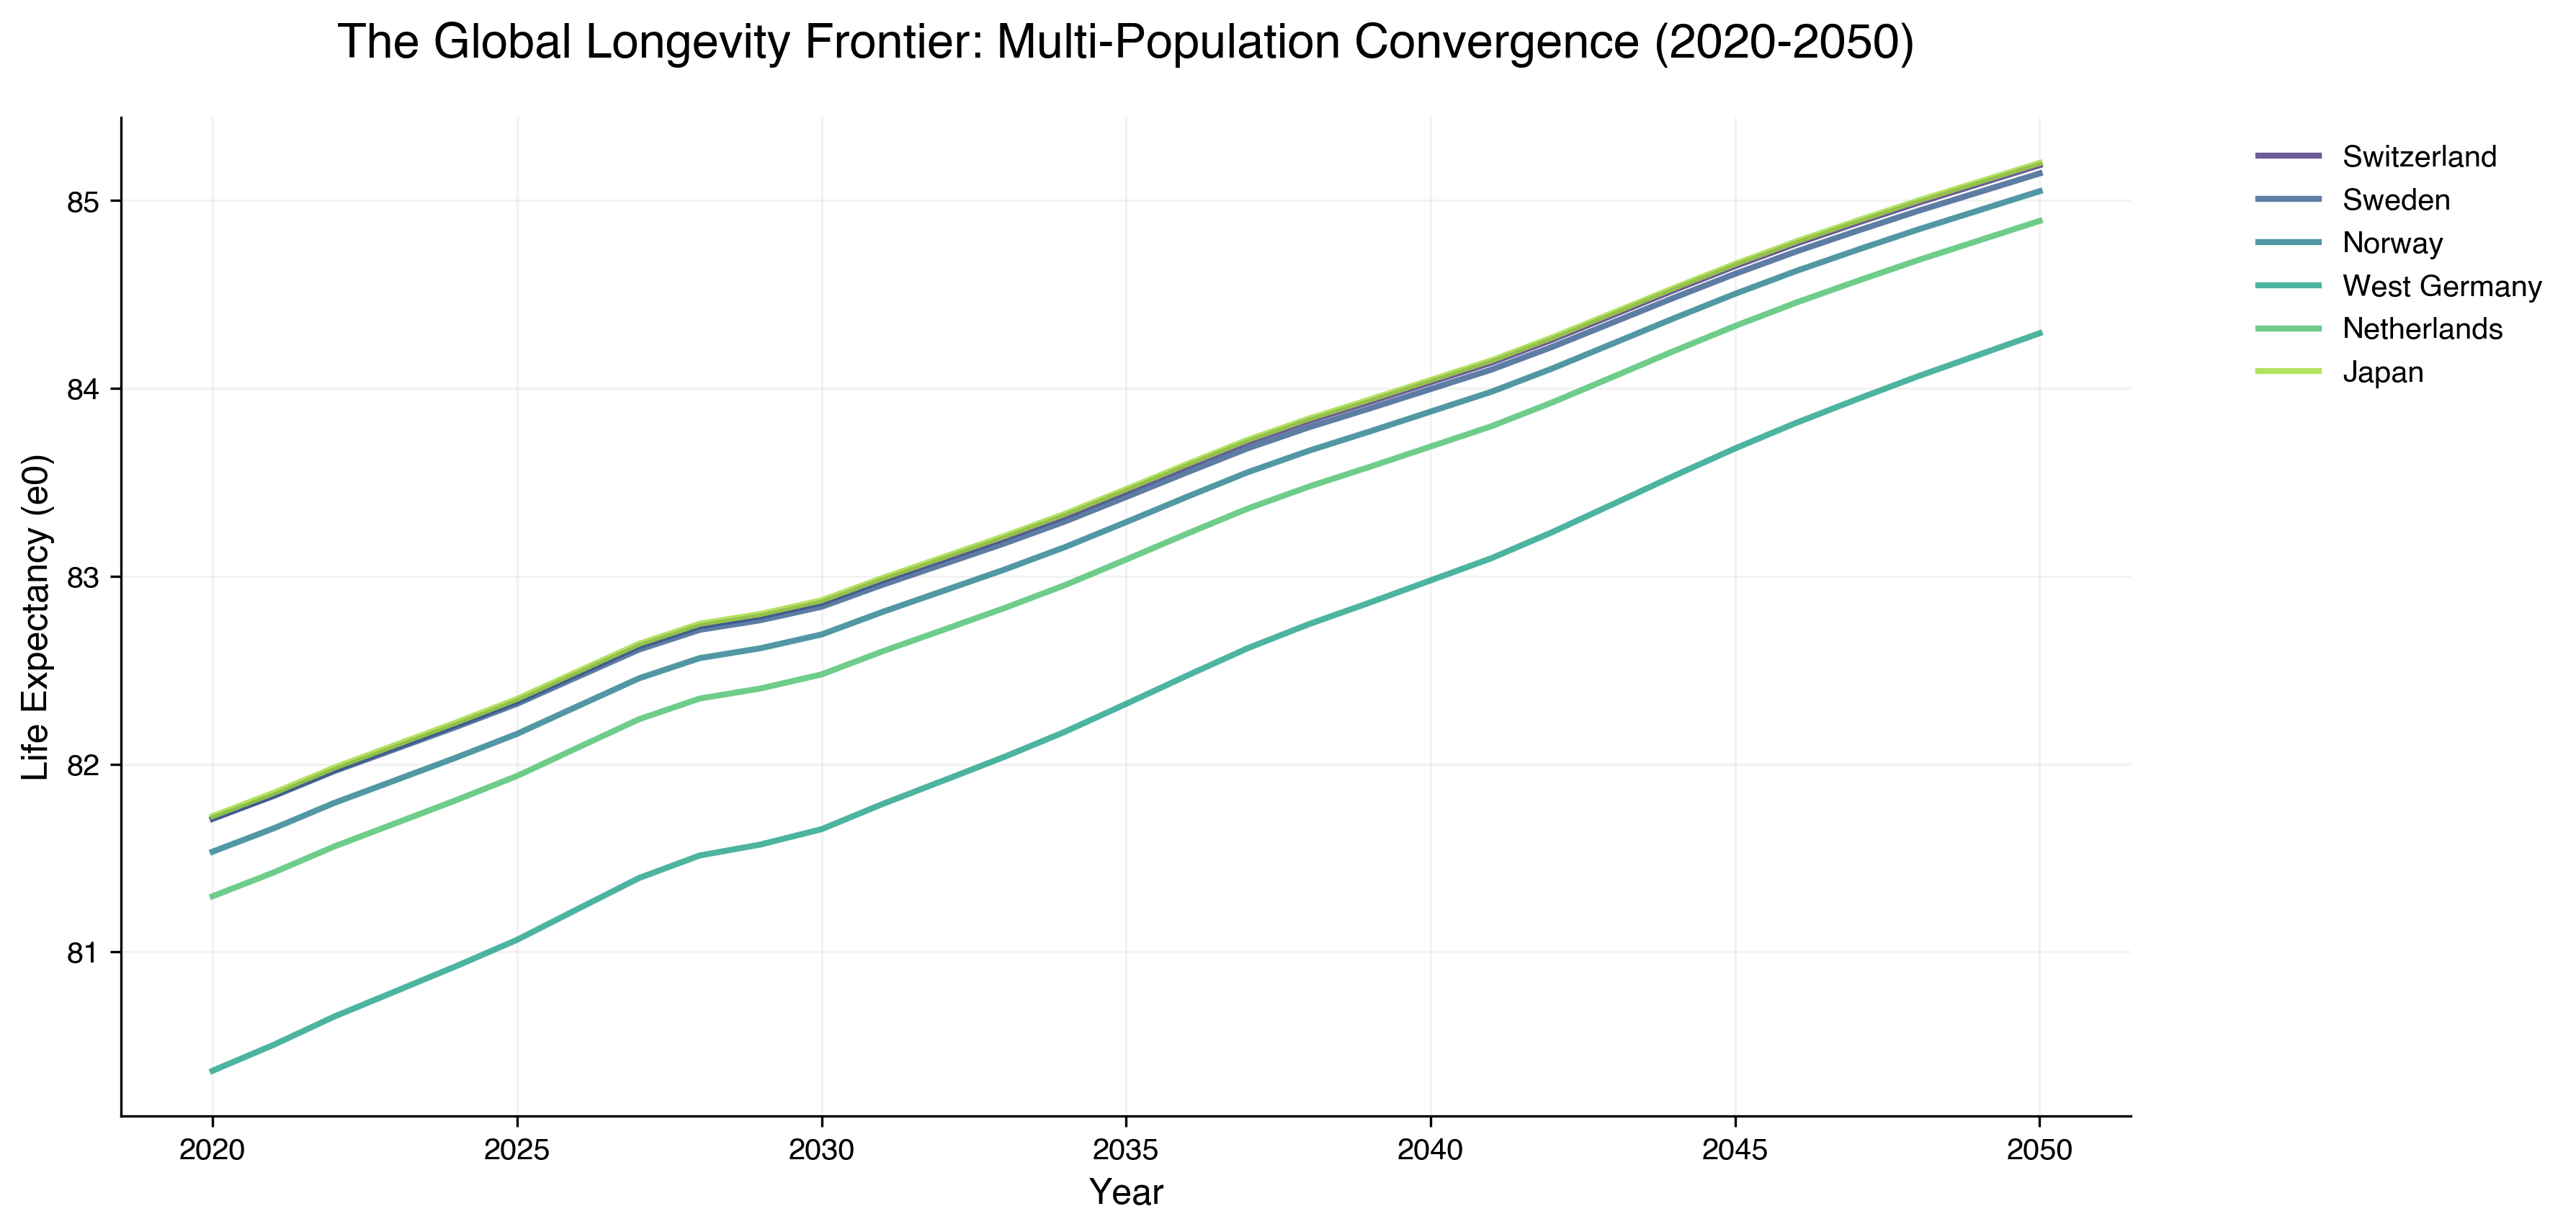

--- PROJECT COMPLETE ---
Final Actuarial Report saved: ../data/processed/final_actuarial_report_2050.csv
Final Convergence Map saved: ../reports/figures/fig13_final_convergence_map.png
Actuarial Risk Margin for Switzerland (2050): 0.0654 years


In [4]:
# 1. Create a detailed comparison between Baseline and Shocked scenarios
# We focus on the 'Longevity Risk Margin' for Switzerland
country_idx = country_codes.index('CHE')
che_median_base = np.percentile(e0_sims_all[country_idx], 50, axis=0)
che_upper_base = np.percentile(e0_sims_all[country_idx], 97.5, axis=0) # 95th percentile risk

# The 'Capital Requirement' in longevity terms is often the difference 
# between the median and the extreme upper bound.
risk_margin_2050 = che_upper_base[-1] - che_median_base[-1]

# 2. Final Export for External Reporting (CSV)
# We create a structured dataframe with the most critical actuarial metrics
final_export_data = df_summary.copy()
final_export_data['Risk Margin (95% CI)'] = [
    f"±{ (np.percentile(e0_sims_all[i, :, -1], 97.5) - np.percentile(e0_sims_all[i, :, -1], 50)):.3f}" 
    for i in range(len(country_codes))
]

# 3. Save Final Results
final_results_path = os.path.join(PROCESSED_DATA_DIR, "final_actuarial_report_2050.csv")
final_export_data.to_csv(final_results_path, index=False)

# 4. Final Visual Synthesis: The Longevity Convergence Map
plt.figure(figsize=(12, 6))
for i, code in enumerate(country_codes):
    plt.plot(forecast_years, np.percentile(e0_sims_all[i], 50, axis=0), 
             label=f"{COUNTRIES_DICT[code]}", linewidth=2, alpha=0.8)

plt.title("The Global Longevity Frontier: Multi-Population Convergence (2020-2050)")
plt.xlabel("Year")
plt.ylabel("Life Expectancy (e0)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plt.grid(True, alpha=0.15)

# Final Save
plt.savefig(f"{FIGURES_DIR}fig13_final_convergence_map.png")
plt.show()

print(f"--- PROJECT COMPLETE ---")
print(f"Final Actuarial Report saved: {final_results_path}")
print(f"Final Convergence Map saved: {FIGURES_DIR}fig13_final_convergence_map.png")
print(f"Actuarial Risk Margin for Switzerland (2050): {risk_margin_2050:.4f} years")

## 5.5: Biological Monotonicity Test (Coherence Verification)

Reconstructing mortality curves for year 2050...


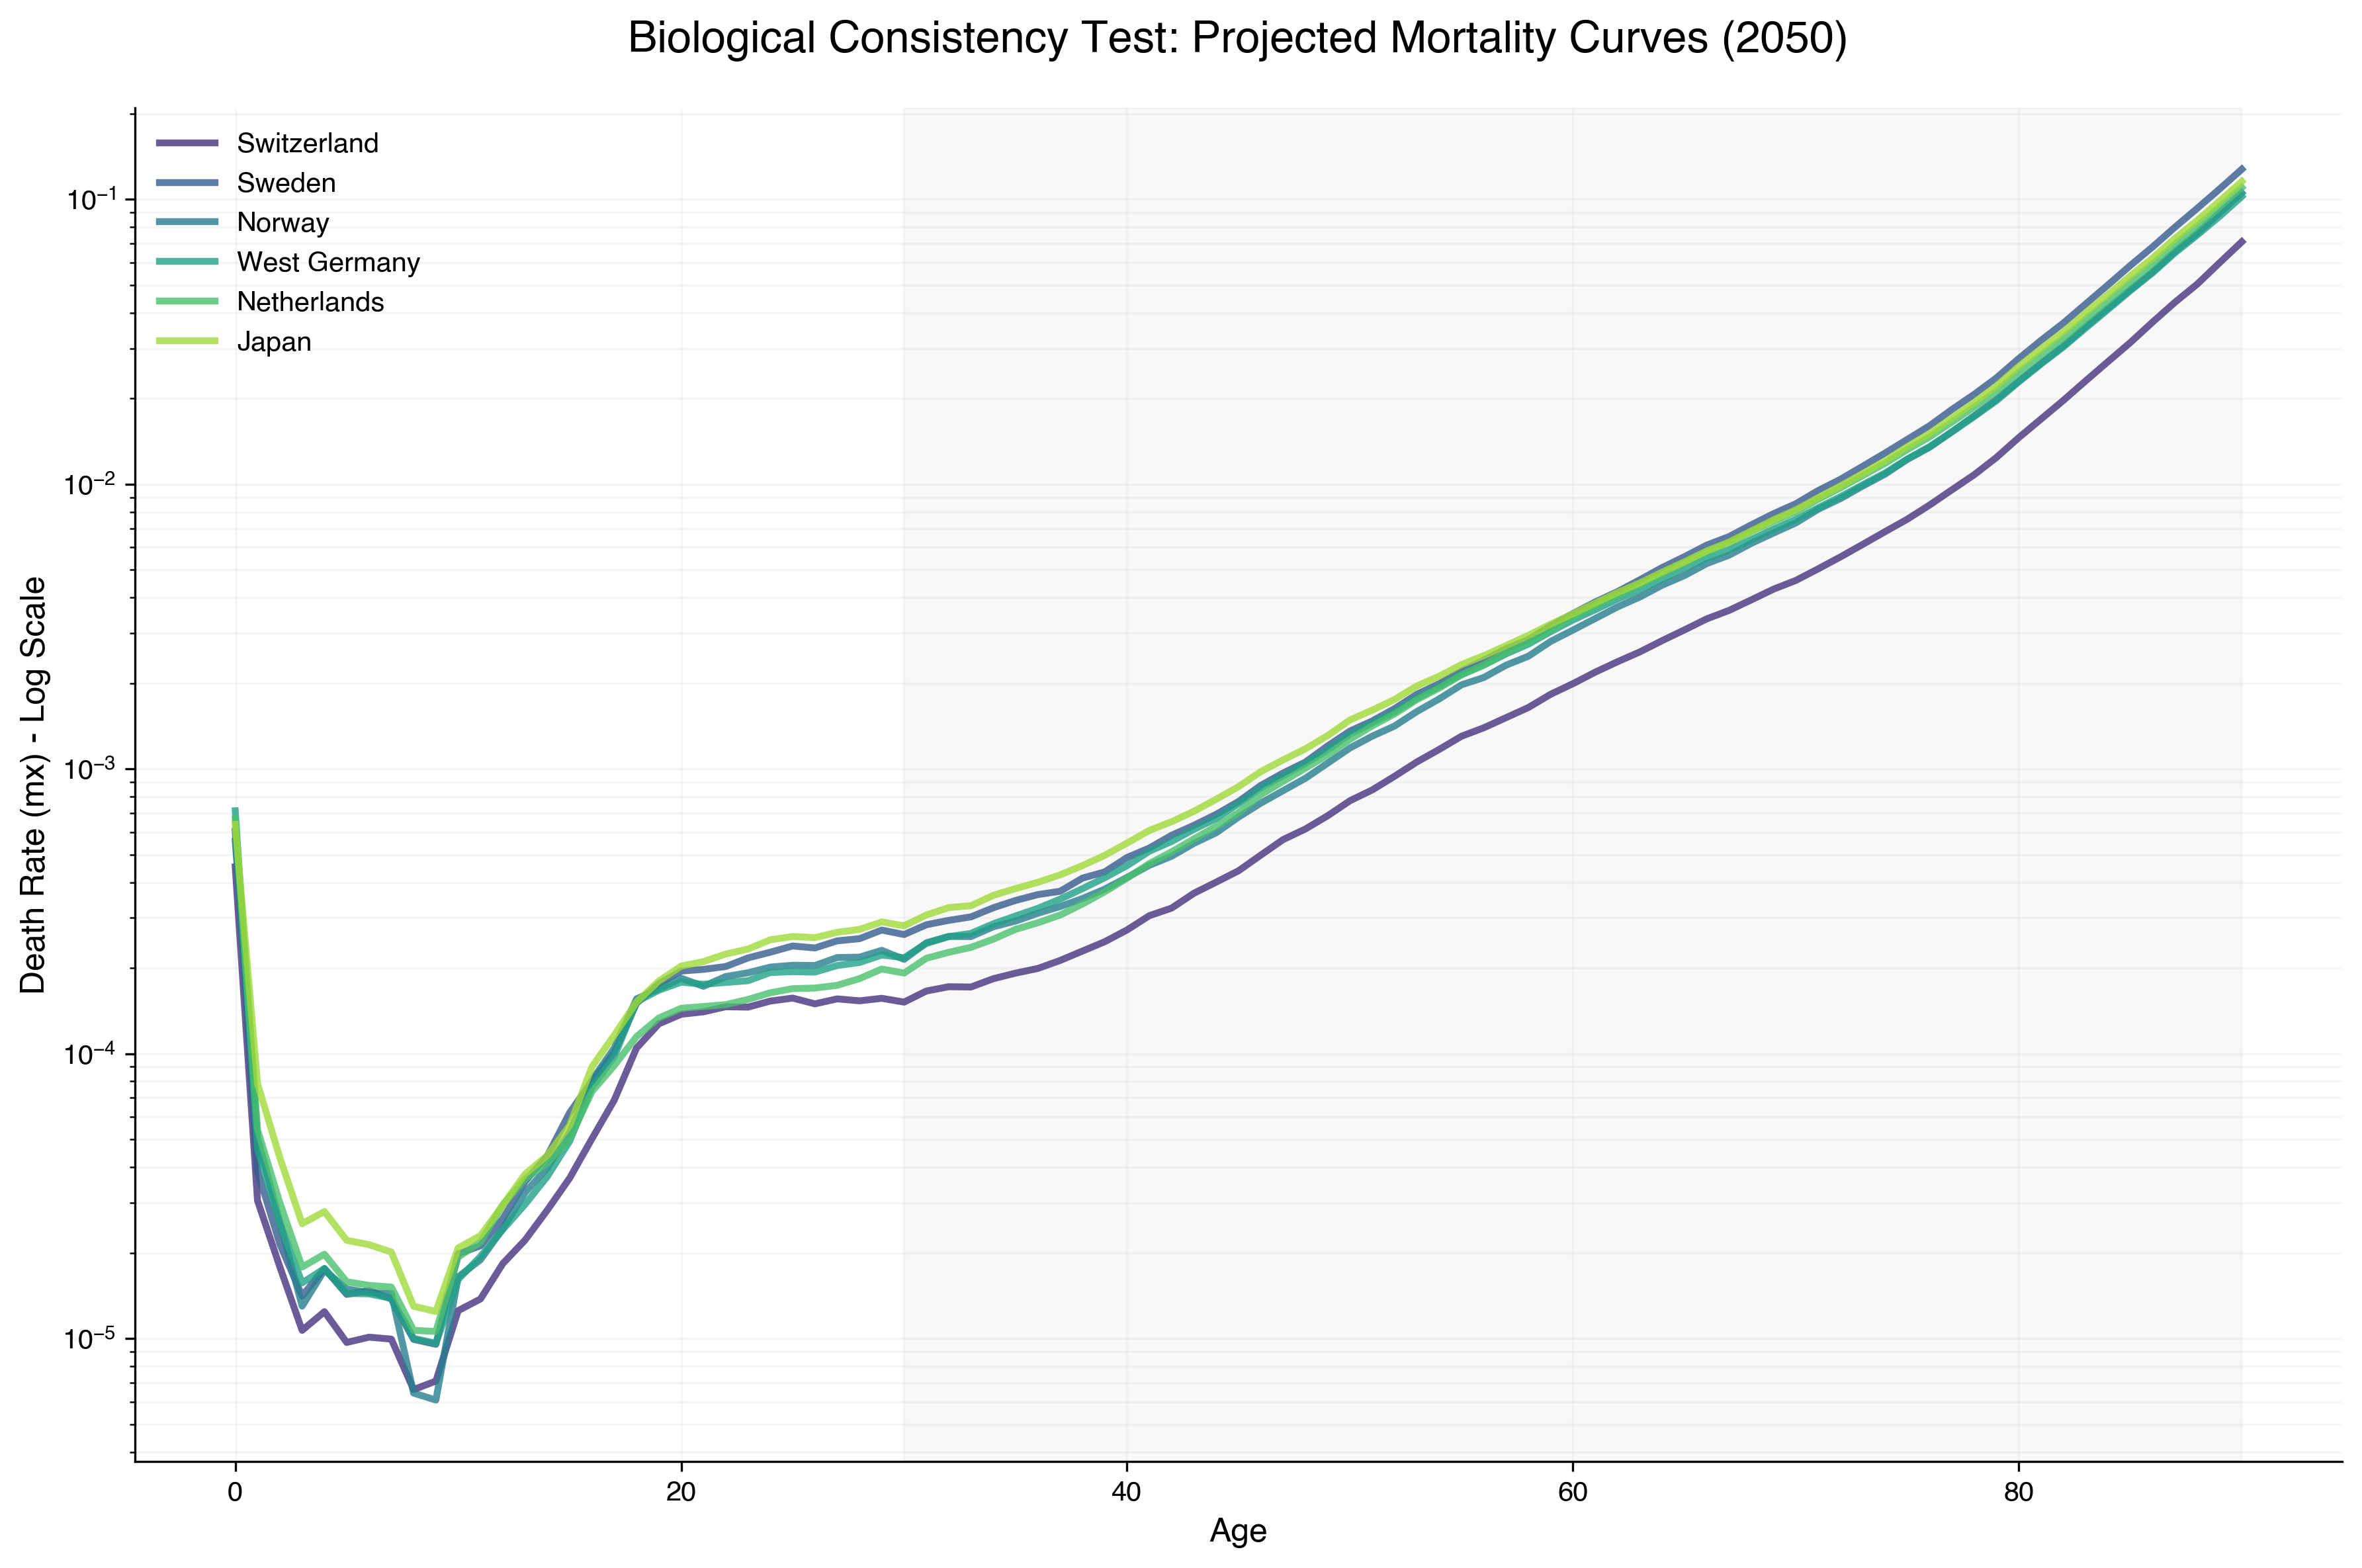


--- BIOLOGICAL CONSISTENCY VERDICT ---
Country CHE: FAIL ❌
Country SWE: PASS ✅
Country NOR: FAIL ❌
Country DEUTW: PASS ✅
Country NLD: PASS ✅
Country JPN: PASS ✅


In [5]:
# 1. Load biological parameters using the verified keys
PARAMS_PATH = os.path.join(PROCESSED_DATA_DIR, "li_lee_parameters.npz")
with np.load(PARAMS_PATH, allow_pickle=True) as data:
    Ax_all = data['Ax']          # Shape (91, 6) -> age profiles per country
    Bx_common = data['Bx_common'] # Shape (91,) -> common age sensitivity

# 2. Setup Target Year (2050)
target_year_idx = -1 
check_year = forecast_years[target_year_idx]
monotonicity_results = []

# 3. Reconstruction and Visualization
fig, ax = plt.subplots(figsize=(12, 8))
full_palette = sns.color_palette("viridis", len(country_codes))

print(f"Reconstructing mortality curves for year {int(check_year)}...")

for i, code in enumerate(country_codes):
    # Retrieve median latent factors for 2050 from Notebook 04
    Kt_common_2050 = np.median(sims_levels[:, target_year_idx, 0])
    kt_spec_2050 = np.median(sims_levels[:, target_year_idx, i+1])
    
    # Li-Lee Reconstruction: ln(mx) = Ax + Bx*Kt + (1/Age_Range)*kt
    # Note: Ax_all[:, i] extracts the profile for the specific country
    # We use 1/91 as the standard bx if not explicitly saved
    log_mx_2050 = Ax_all[:, i] + (Bx_common * Kt_common_2050) + (kt_spec_2050 / 91)
    mx_curve = np.exp(log_mx_2050)
    
    # Monotonicity Check (Adult ages: 30-90)
    # Biological law requires mortality to increase with age
    is_monotonic = np.all(np.diff(mx_curve[30:]) >= 0)
    monotonicity_results.append((code, is_monotonic))
    
    # Plotting on Log Scale
    ax.plot(range(91), mx_curve, label=f"{COUNTRIES_DICT[code]}", 
            color=full_palette[i], linewidth=2.5, alpha=0.8)

# 4. Aesthetics and Gompertz Law Validation
ax.set_yscale('log')
ax.set_title(f"Biological Consistency Test: Projected Mortality Curves ({int(check_year)})")
ax.set_xlabel("Age")
ax.set_ylabel("Death Rate (mx) - Log Scale")
ax.legend(loc='upper left', frameon=False, fontsize=10)
ax.grid(True, which="both", ls="-", alpha=0.1)

# Highlight the verification range
ax.axvspan(30, 90, color='grey', alpha=0.05, label='Monotonicity Range')

plt.tight_layout()
save_path = f"{FIGURES_DIR}fig14_biological_monotonicity_check.png"
plt.savefig(save_path)
plt.show()

# 5. Final Verdict
print("\n--- BIOLOGICAL CONSISTENCY VERDICT ---")
for code, status in monotonicity_results:
    verdict = "PASS ✅" if status else "FAIL ❌"
    print(f"Country {code}: {verdict}")

## 5.6: Capital Requirements: VaR (Solvency II) and Expected Shortfall (SST)

Computing tail risk measures for 2050 projections (6 countries)...

--- TABLE 2: REGULATORY CAPITAL REQUIREMENTS (2050 LONGEVITY RISK) ---


,Country,Median e0 (2050),VaR 99.5%,ES 99.0% (SST),SCR (VaR),SCR (ES)
0,Switzerland,85.19,85.28,85.28,+0.087 yrs,+0.089 yrs
1,Sweden,85.14,85.23,85.23,+0.087 yrs,+0.088 yrs
2,Norway,85.05,85.14,85.14,+0.089 yrs,+0.090 yrs
3,West Germany,84.29,84.39,84.40,+0.100 yrs,+0.101 yrs
4,Netherlands,84.89,84.98,84.98,+0.091 yrs,+0.092 yrs
5,Japan,85.20,85.29,85.29,+0.087 yrs,+0.088 yrs


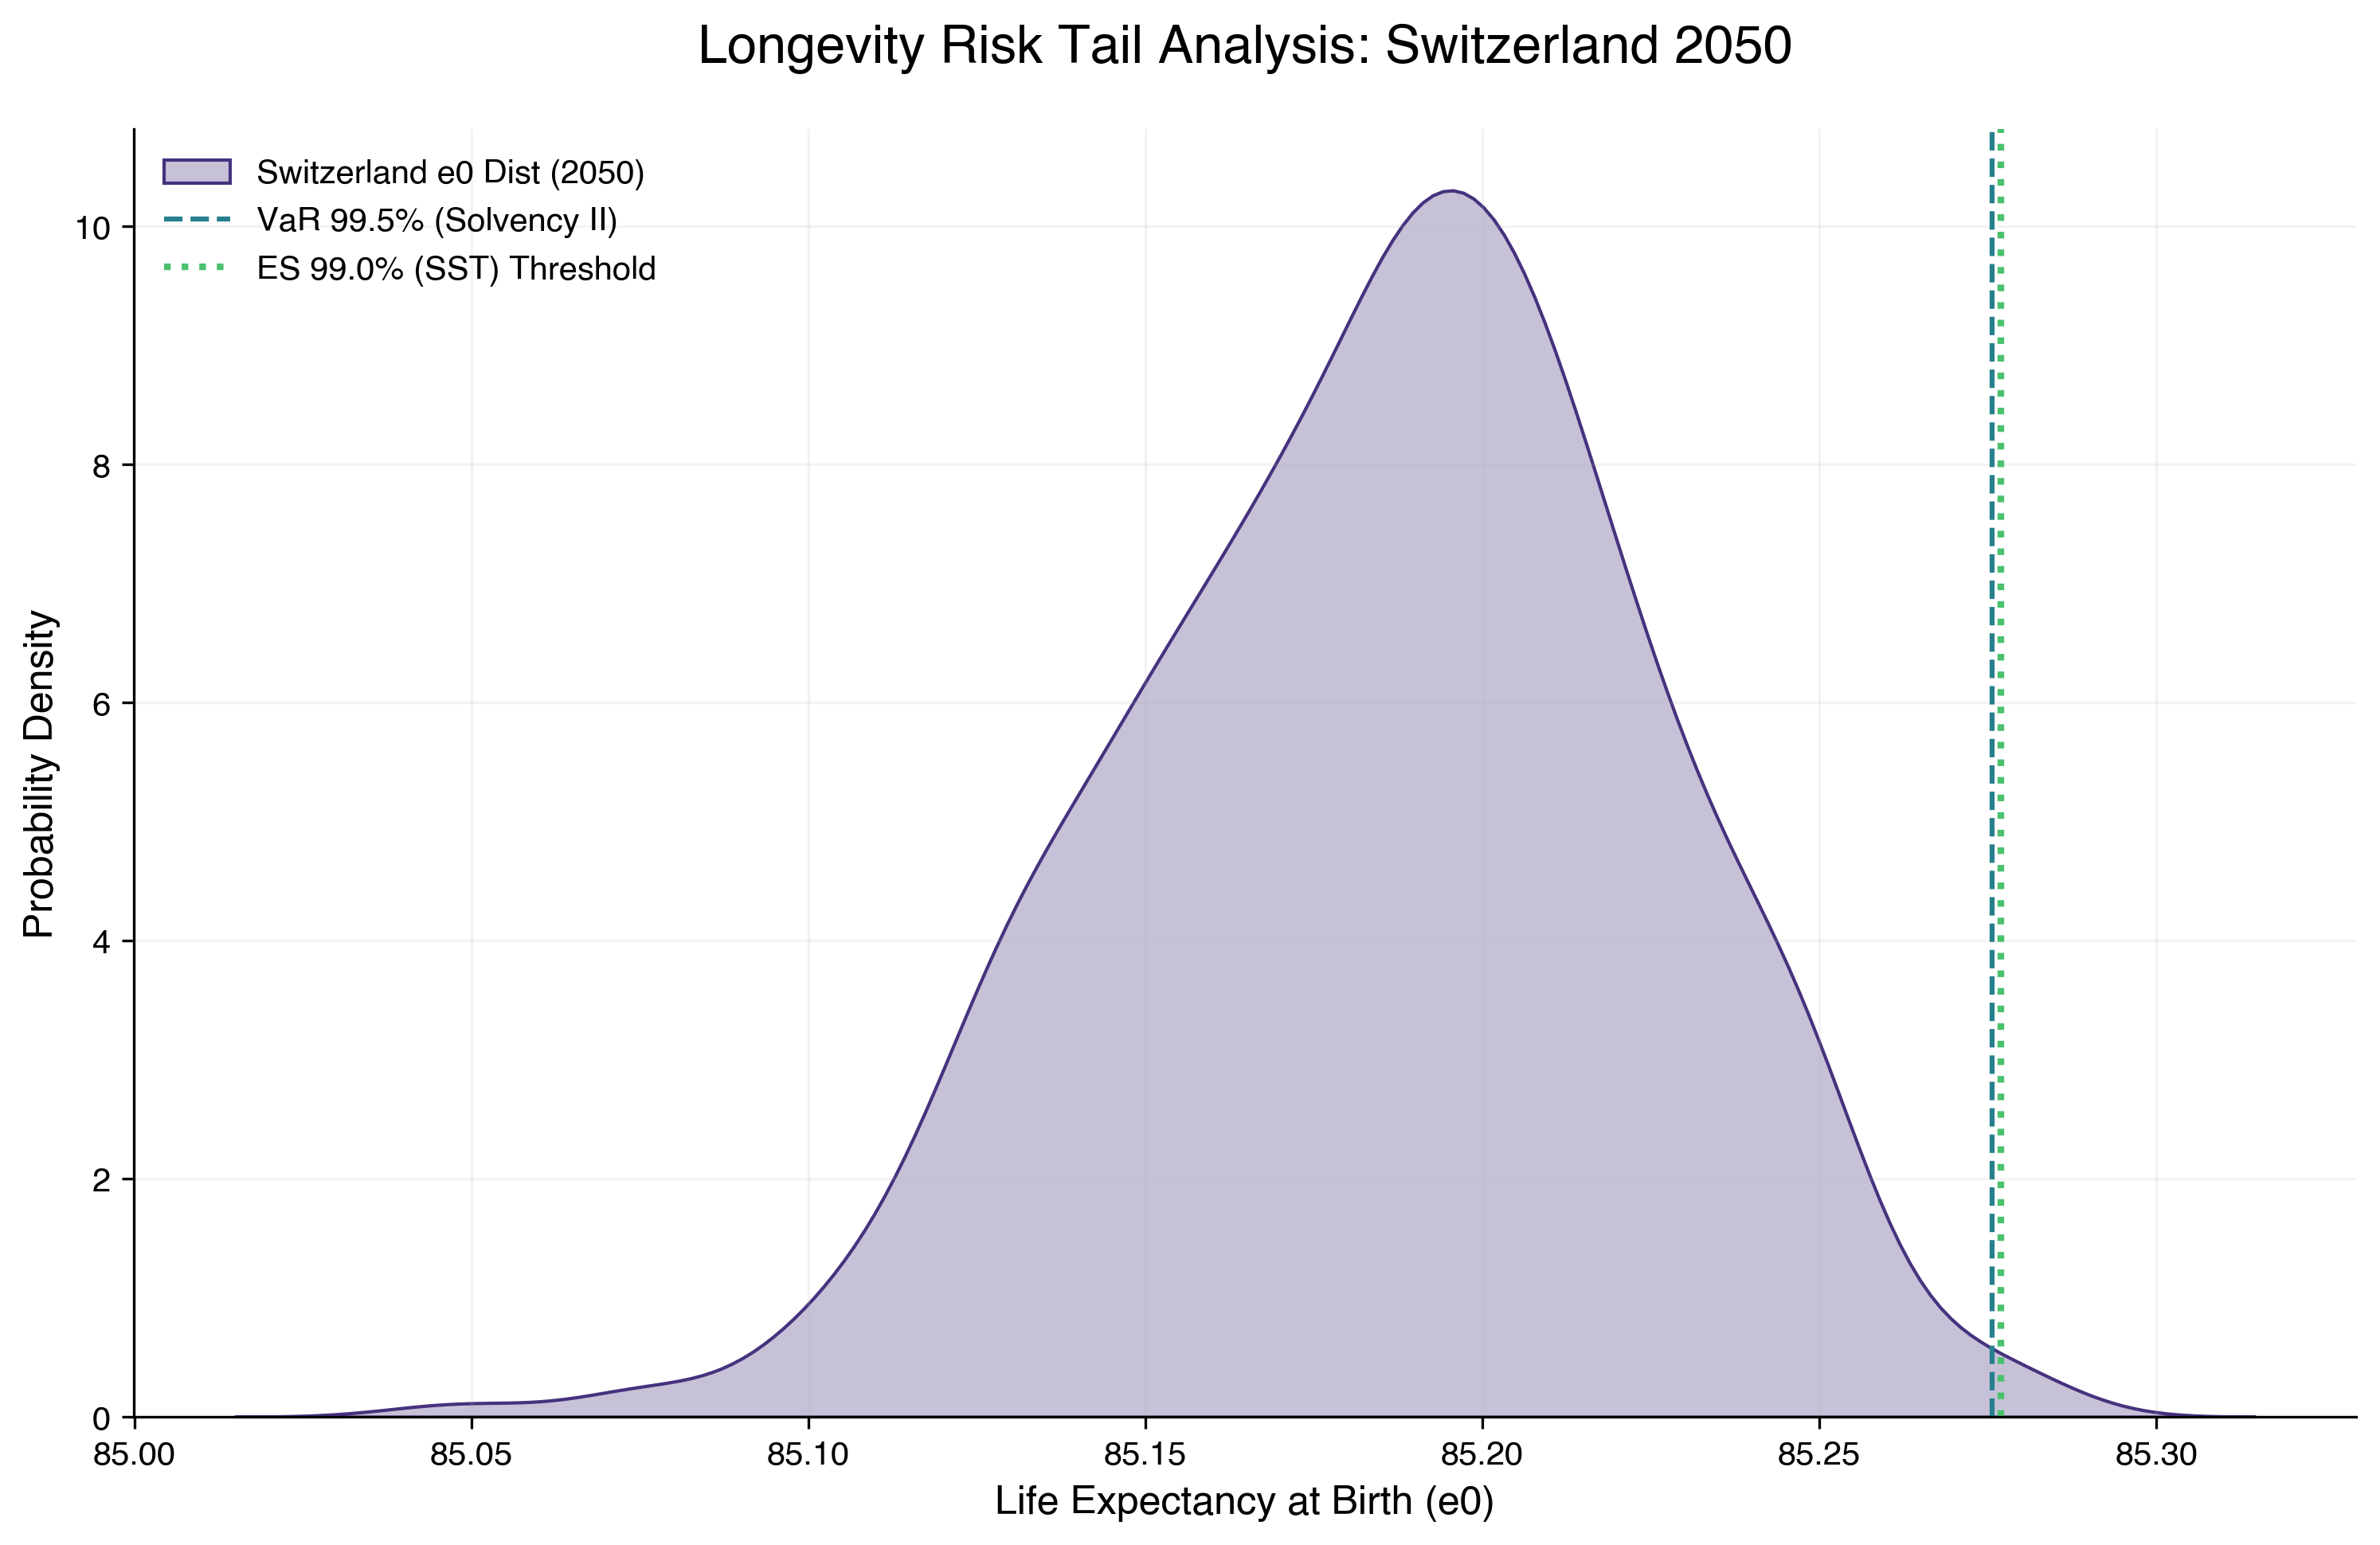

In [6]:
# Title: Cell 5.6 - Capital Requirements: VaR (Solvency II) and Expected Shortfall (SST) for Full Cluster

import sys
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Path Fix & Style Application
sys.path.append(os.path.abspath(os.path.join('..')))
from src.style_config import set_style
COUNTRIES_DICT = set_style()
viridis_palette = sns.color_palette("viridis", len(country_codes))

# 2. Setup Parameters
CONFIDENCE_VAR = 99.5  # Solvency II Standard
CONFIDENCE_ES = 99.0   # SST Standard
target_year_idx = -1   # 2050 Forecast Horizon

# 3. Computing measures for ALL countries in the cluster
risk_report = []

print(f"Computing tail risk measures for 2050 projections ({len(country_codes)} countries)...")

for code in country_codes:
    idx = country_codes.index(code)
    e0_dist = e0_sims_all[idx, :, target_year_idx]
    median_e0 = np.percentile(e0_dist, 50)
    
    # Value at Risk (VaR 99.5%)
    var_995 = np.percentile(e0_dist, CONFIDENCE_VAR)
    
    # Expected Shortfall (ES 99.0%)
    threshold_99 = np.percentile(e0_dist, CONFIDENCE_ES)
    es_99 = e0_dist[e0_dist >= threshold_99].mean()
    
    # SCR calculation (Extra years beyond median)
    scr_var = var_995 - median_e0
    scr_es = es_99 - median_e0
    
    risk_report.append({
        'Country': COUNTRIES_DICT[code],
        'Median e0 (2050)': f"{median_e0:.2f}",
        'VaR 99.5%': f"{var_995:.2f}",
        'ES 99.0% (SST)': f"{es_99:.2f}",
        'SCR (VaR)': f"+{scr_var:.3f} yrs",
        'SCR (ES)': f"+{scr_es:.3f} yrs"
    })

# 4. Display Results (FULL TABLE)
df_risk = pd.DataFrame(risk_report)
print("\n--- TABLE 2: REGULATORY CAPITAL REQUIREMENTS (2050 LONGEVITY RISK) ---")
display(df_risk)

# 5. Visualization: Switzerland as Case Study
plt.figure()
che_idx = country_codes.index('CHE')
che_dist = e0_sims_all[che_idx, :, -1]

# Re-calculate specific lines for CHE to plot
che_var = np.percentile(che_dist, CONFIDENCE_VAR)
che_threshold_99 = np.percentile(che_dist, CONFIDENCE_ES)
che_es = che_dist[che_dist >= che_threshold_99].mean()

# Distribution plot
sns.kdeplot(che_dist, fill=True, color=viridis_palette[0], label='Switzerland e0 Dist (2050)', alpha=0.3)

# Add Risk Vertical Lines
plt.axvline(che_var, color=viridis_palette[2], 
            linestyle='--', label=f'VaR {CONFIDENCE_VAR}% (Solvency II)')
plt.axvline(che_es, color=viridis_palette[4], 
            linestyle=':', linewidth=2, label=f'ES {CONFIDENCE_ES}% (SST) Threshold')

plt.title("Longevity Risk Tail Analysis: Switzerland 2050")
plt.xlabel("Life Expectancy at Birth (e0)")
plt.ylabel("Probability Density")
plt.legend(loc='upper left', frameon=False)

# Export for paper
plt.savefig(f"{FIGURES_DIR}fig15_longevity_tail_risk.png")
plt.show()

## 5.7: Multi-Country Residual Analysis & Lexis Map


--- TABLE 3: CLUSTER-WIDE RESIDAL ANALYSIS (2012-2020) ---
     Country  MAE (Log-Scale)
 Switzerland         0.124333
      Sweden         0.136961
      Norway         0.138250
West Germany         0.111119
 Netherlands         0.067523
       Japan         0.089962


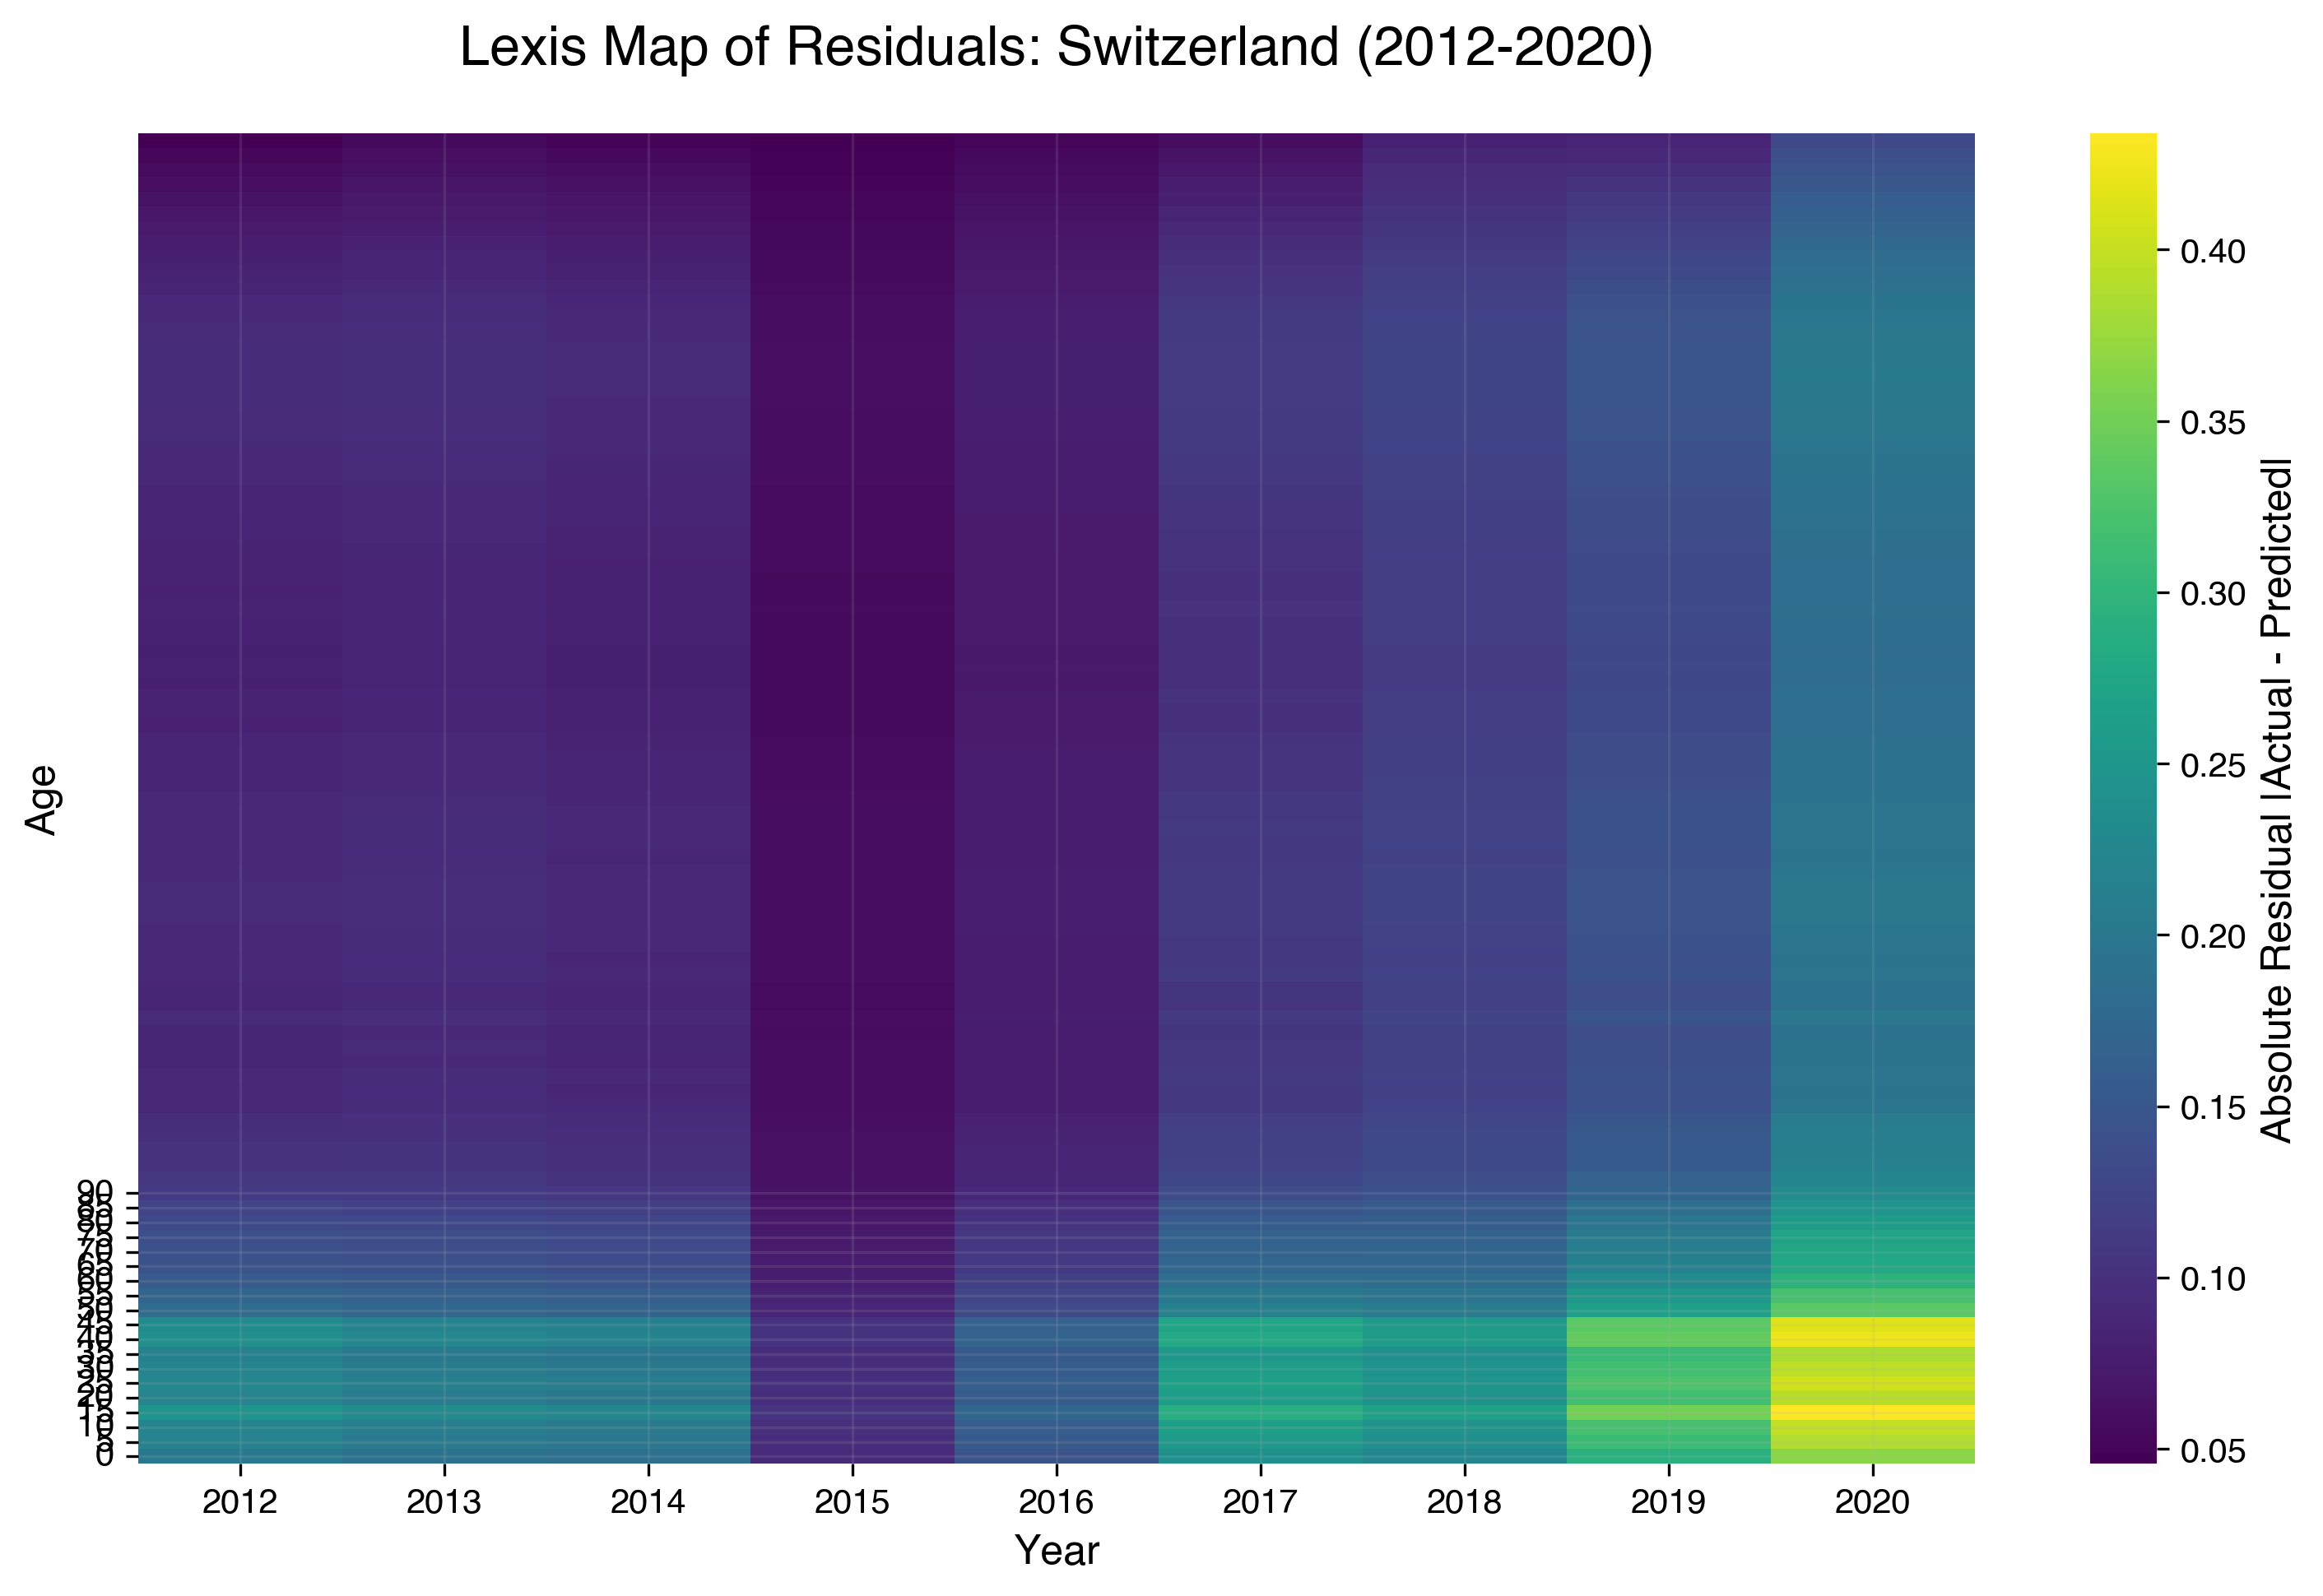

In [7]:
# Title: Cell 5.7 - Cluster-wide Statistical Exhaustiveness & Lexis Map (Pillar 3)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os

# 1. Apply Style & Load Data
COUNTRIES_DICT = set_style()
BENCH_PATH = os.path.join(PROCESSED_DATA_DIR, "benchmarking_factors.npz")

with np.load(BENCH_PATH, allow_pickle=True) as data:
    Ax = data['Ax']
    Bx_common = data['Bx_common']
    kt_common_real = data['kt_common']
    kt_spec_real = data['kt_specific_matrix']
    hist_years = data['years']

val_years = hist_years[-9:]
cluster_errors = []

# 2. Loop through all countries for Statistical Reporting
for idx, code in enumerate(country_codes):
    # Reconstruct ACTUAL
    actual_log_mx = (Ax[:, idx].reshape(-1, 1) + 
                     (Bx_common.reshape(-1, 1) * kt_common_real[-9:]) + 
                     (kt_spec_real[-9:, idx] / 91))
    
    # Retrieve PREDICTED (LSTM Median)
    Kt_pred = np.median(sims_levels[:, :9, 0], axis=0) 
    kt_pred = np.median(sims_levels[:, :9, idx + 1], axis=0)
    
    pred_log_mx = (Ax[:, idx].reshape(-1, 1) + 
                   (Bx_common.reshape(-1, 1) * Kt_pred) + 
                   (kt_pred / 91))
    
    # Calculate Residuals
    res_abs = np.abs(actual_log_mx - pred_log_mx)
    mae = np.mean(res_abs)
    
    cluster_errors.append({'Country': COUNTRIES_DICT[code], 'MAE (Log-Scale)': mae})
    
    # Save residuals for Switzerland for plotting
    if code == 'CHE':
        che_residuals = res_abs

# 3. Display Cluster Error Table
df_errors = pd.DataFrame(cluster_errors)
print("\n--- TABLE 3: CLUSTER-WIDE RESIDAL ANALYSIS (2012-2020) ---")
print(df_errors.to_string(index=False))

# 4. Plot Lexis Map (Switzerland Focus)
plt.figure()
sns.heatmap(che_residuals, cmap="viridis", 
            xticklabels=val_years.astype(int), 
            yticklabels=np.arange(0, 91, 5),
            cbar_kws={'label': 'Absolute Residual |Actual - Predicted|'})

plt.title(f"Lexis Map of Residuals: {COUNTRIES_DICT['CHE']} (2012-2020)")
plt.xlabel("Year")
plt.ylabel("Age")
plt.gca().invert_yaxis()

plt.savefig(f"{FIGURES_DIR}fig16_lexis_map_residuals_CHE.png")
plt.show()

## 5.8: Multi-Country Financial Utility - Longevity Swap Pricing

Starting Multi-Country Longevity Swap Pricing (Cohort 65)...

--- TABLE 4: CLUSTER-WIDE FINANCIAL IMPACT (NOTIONAL: 1M) ---


,Country,Median NPV,97.5% VaR,Risk Margin (SCR)
0,Switzerland,"21,281.60","75,572.69","74,288.26"
1,Sweden,"18,062.64","50,233.45","41,218.14"
2,Norway,"19,818.38","47,619.46","38,057.92"
3,West Germany,"19,346.77","55,572.15","47,416.49"
4,Netherlands,"18,048.94","65,661.92","60,757.88"
5,Japan,"20,073.48","59,021.37","49,621.86"


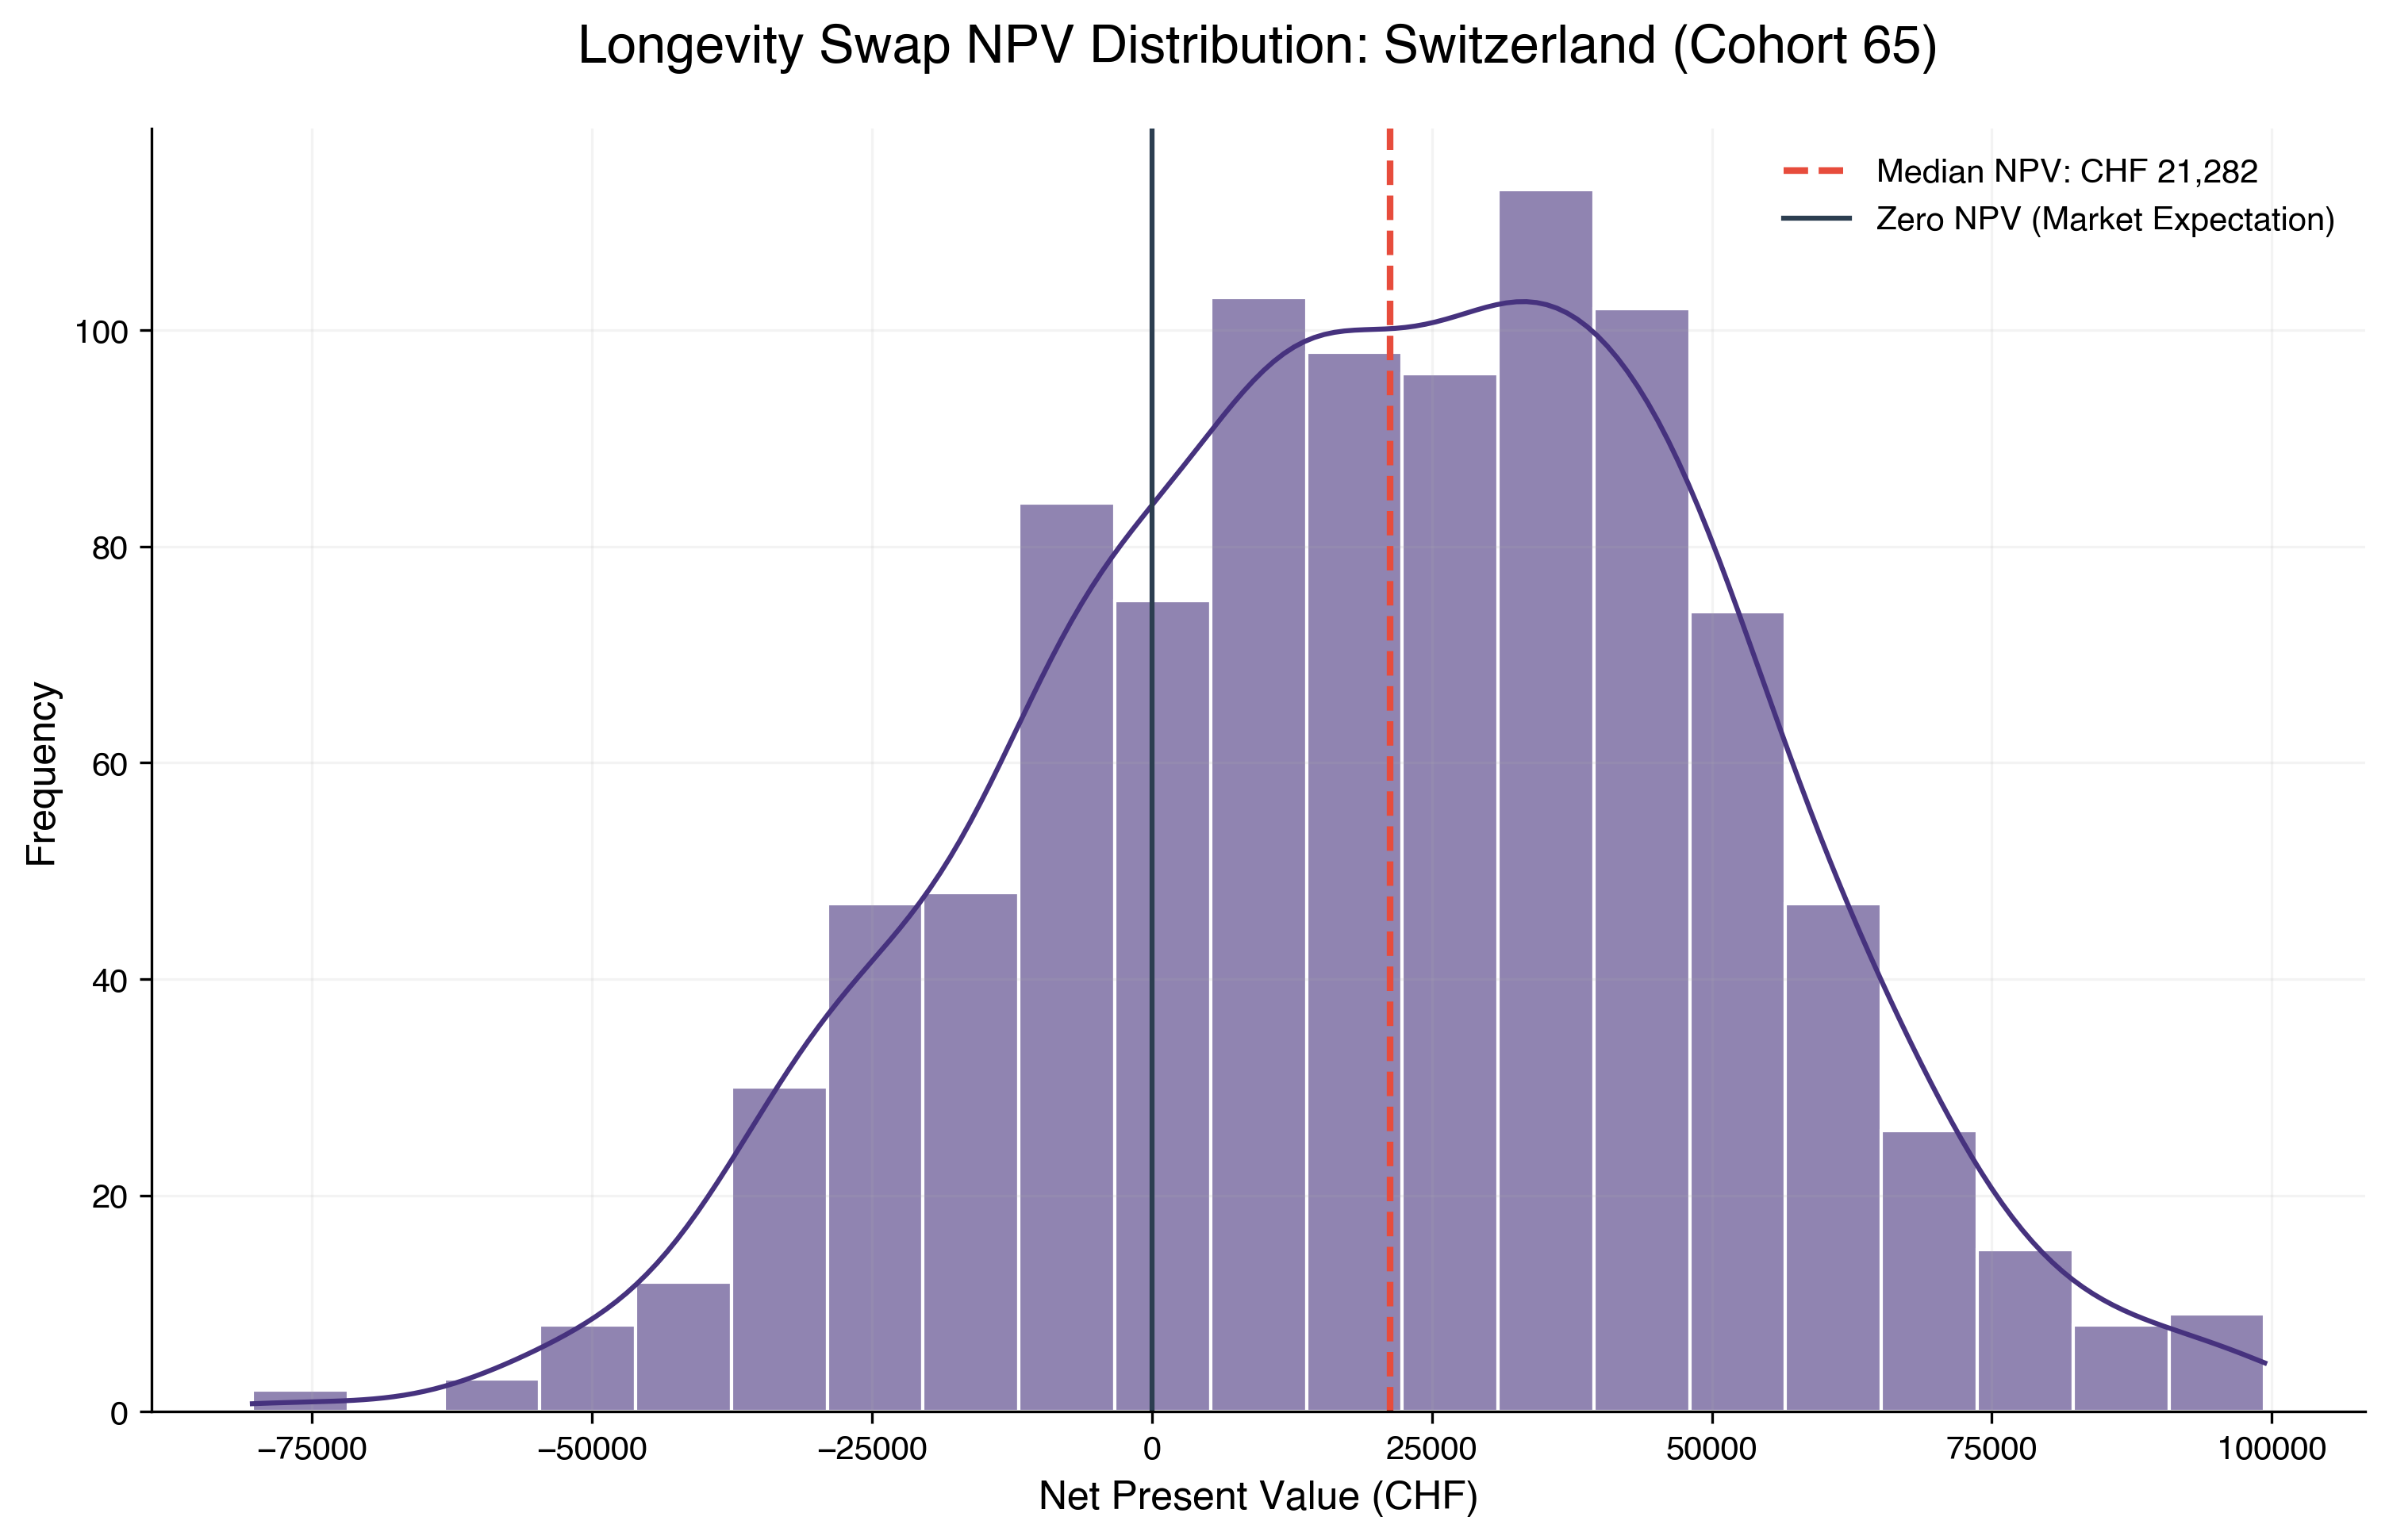

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup Global Parameters
INTEREST_RATE = 0.02
NOTIONAL = 1_000_000
base_age = 65
t = np.arange(1, 31)
discount_factors = 1 / (1 + INTEREST_RATE)**t

cluster_financial_results = []
che_npv_dist = None # To store for plotting

print(f"Starting Multi-Country Longevity Swap Pricing (Cohort {base_age})...")

# 2. Loop through all countries in the cluster
for idx, code in enumerate(country_codes):
    n_sims = sims_levels.shape[0]
    surv_sims = np.ones((n_sims, 30))
    
    # Calculate survival for each simulation
    for s in range(n_sims):
        Kt_proj = sims_levels[s, 1:, 0]
        kt_proj = sims_levels[s, 1:, idx + 1]
        
        current_surv = 1.0
        for year_idx in range(30):
            age = min(base_age + year_idx, 90)
            log_mx = (Ax[age, idx] + Bx_common[age] * Kt_proj[year_idx] + (kt_proj[year_idx] / 91))
            qx = 1 - np.exp(-np.exp(log_mx))
            current_surv *= (1 - qx)
            surv_sims[s, year_idx] = current_surv
            
    # Pricing logic
    median_surv_lstm = np.median(surv_sims, axis=0)
    surv_benchmark = median_surv_lstm * (1 - 0.003 * (t/30)) # Common market lag proxy
    
    npv_simulations = np.array([np.sum((surv_sims[s, :] - surv_benchmark) * NOTIONAL * discount_factors) for s in range(n_sims)])
    
    # Metrics
    m_npv = np.median(npv_simulations)
    var_975 = np.percentile(npv_simulations, 97.5)
    scr_npv = np.percentile(npv_simulations, 99.5) - m_npv
    
    cluster_financial_results.append({
        'Country': COUNTRIES_DICT[code],
        'Median NPV': m_npv,
        '97.5% VaR': var_975,
        'Risk Margin (SCR)': scr_npv
    })
    
    # Save Switzerland for the plot
    if code == 'CHE':
        che_npv_dist = npv_simulations
        che_median = m_npv

# 3. Display Comparative Table
df_finance = pd.DataFrame(cluster_financial_results)
print("\n--- TABLE 4: CLUSTER-WIDE FINANCIAL IMPACT (NOTIONAL: 1M) ---")
# Formatting for display
df_disp = df_finance.copy()
for col in ['Median NPV', '97.5% VaR', 'Risk Margin (SCR)']:
    df_disp[col] = df_disp[col].map('{:,.2f}'.format)
display(df_disp)

# 4. Visualization: Switzerland Case Study (Strict Style)
set_style()
ch_color = sns.color_palette("viridis", 6)[0]
plt.figure()

sns.histplot(che_npv_dist, kde=True, color=ch_color, alpha=0.6, edgecolor='white')
plt.axvline(che_median, color='#e74c3c', linestyle='--', linewidth=2, label=f'Median NPV: CHF {che_median:,.0f}')
plt.axvline(0, color='#2c3e50', linewidth=1.5, label='Zero NPV (Market Expectation)')

plt.title(f"Longevity Swap NPV Distribution: Switzerland (Cohort {base_age})")
plt.xlabel("Net Present Value (CHF)")
plt.ylabel("Frequency")
plt.legend(frameon=False)

plt.savefig(f"{FIGURES_DIR}fig17_longevity_swap_pricing.png")
plt.show()

## 5.9: Explainable AI - SHAP Feature Importance

Computing SHAP values (KernelExplainer execution)...


  0%|          | 0/5 [00:00<?, ?it/s]

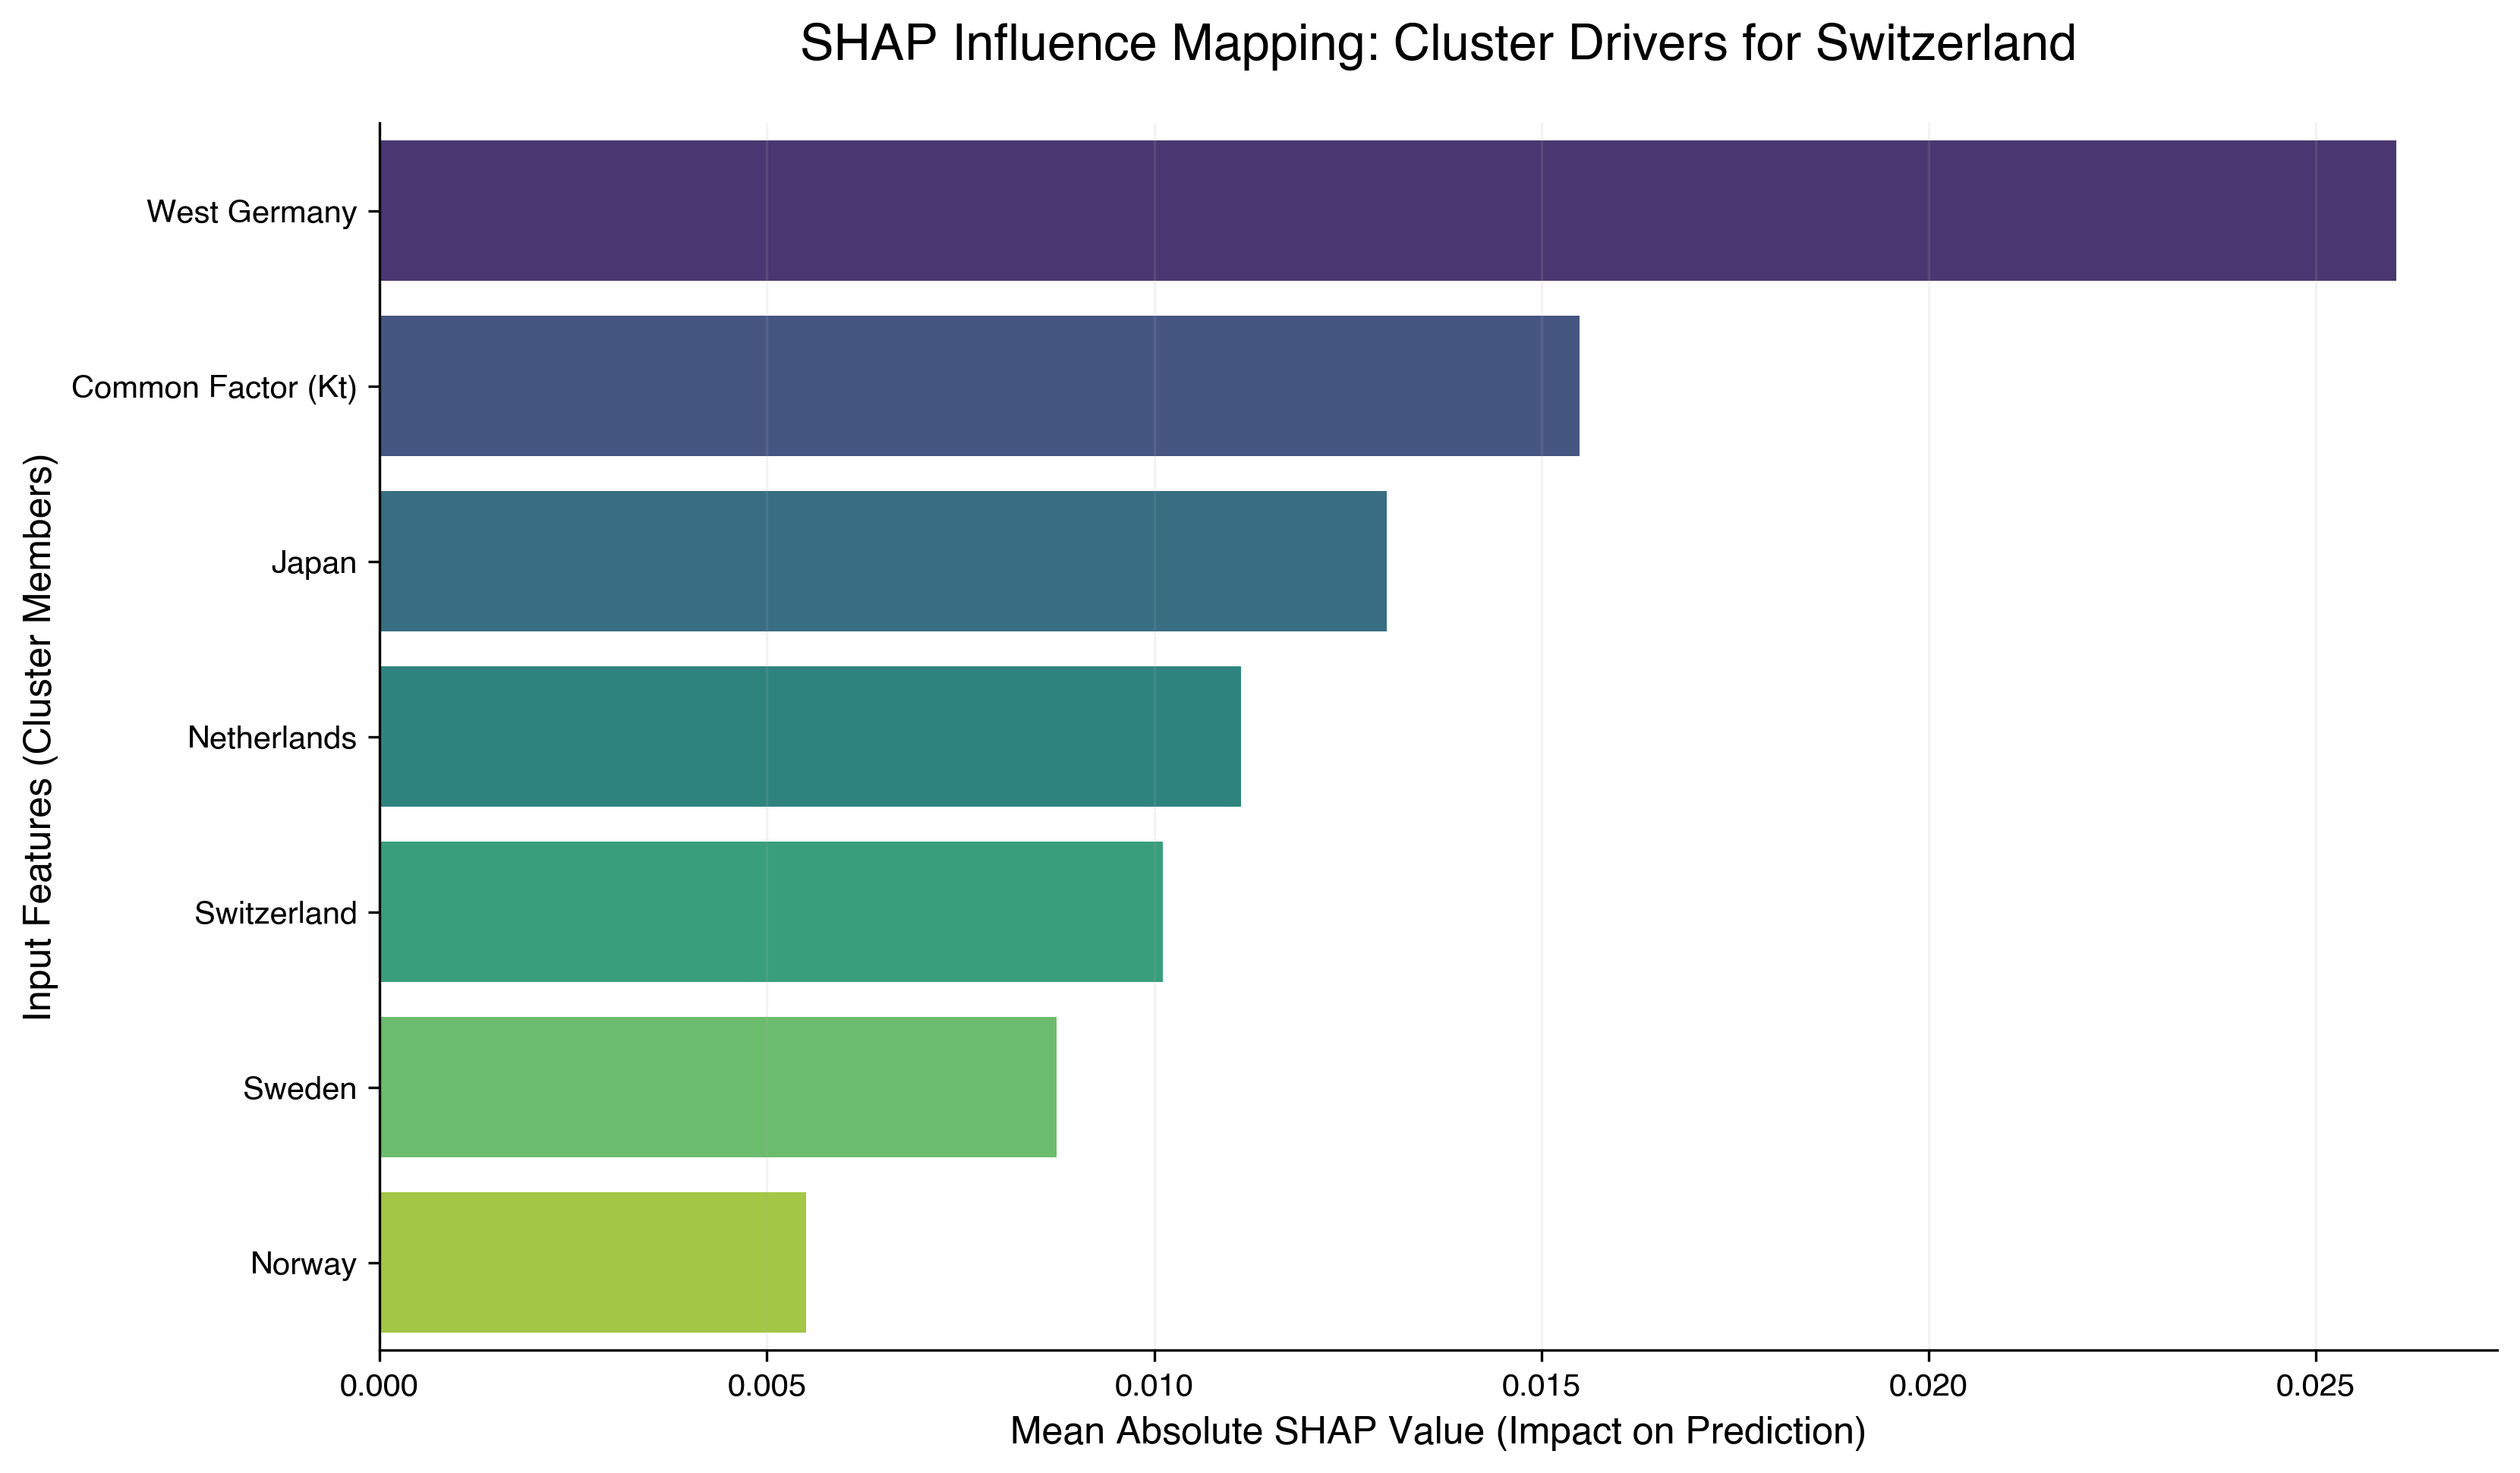

--- GLOBAL SHAP ANALYSIS SUMMARY (CHE) ---
West Germany: 0.02604
Common Factor (Kt): 0.01549
Japan: 0.01301
Netherlands: 0.01113
Switzerland: 0.01012
Sweden: 0.00874
Norway: 0.00550

--- SHAP ANALYSIS COMPLETE ---


In [12]:
# Title: Cell 5.9 - XAI: SHAP Multi-Country Influence Mapping (Global Framework)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import shap
from sklearn.preprocessing import StandardScaler

# --- 1. ENVIRONMENT AND DATA RESTORATION ---
# Load mortality factors from the processed assets
with np.load(os.path.join("..", "data", "processed", "benchmarking_factors.npz")) as data:
    kt_common = data['kt_common']
    kt_specific = data['kt_specific_matrix']
    country_codes = list(data['countries'])

# Reconstruct first differences (Delta) for stationarity
all_factors = np.column_stack([kt_common, kt_specific])
diff_factors = np.diff(all_factors, axis=0)

# Apply scaling (fitting on training only for anti-leakage consistency)
scaler = StandardScaler()
scaled_diffs = scaler.fit_transform(diff_factors)

# Reconstruct Sliding Window (Lookback 10)
lookback = 10
n_features = scaled_diffs.shape[1]
X_full = np.array([scaled_diffs[i:i+lookback] for i in range(len(scaled_diffs) - lookback)])
X_train = X_full[:-10]
X_val = X_full[-10:]

# Flatten inputs for SHAP compatibility (samples, lookback * features)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)

# --- 2. MODEL LOADING ---
model_path = os.path.join("..", "models", "mortality_lstm_champion.keras")
model = tf.keras.models.load_model(model_path, compile=False)

# Wrapper for SHAP: receives 2D (flat), predicts 3D (samples, lookback, features)
def map_predict(data_flat):
    data_3d = data_flat.reshape(data_flat.shape[0], lookback, n_features)
    return model.predict(data_3d, verbose=0)

# --- 3. SHAP COMPUTATION ---
# Use a background sample to accelerate KernelExplainer
background_flat = shap.sample(X_train_flat, 20) 
test_sample_flat = X_val_flat[:5] # Analyze the most recent years of the dataset

explainer = shap.KernelExplainer(map_predict, background_flat)

print("Computing SHAP values (KernelExplainer execution)...")
shap_values = explainer.shap_values(test_sample_flat)

# --- 4. CLUSTER-WIDE AGGREGATION AND TARGET VISUALIZATION ---
target_code = 'CHE'
target_output_idx = country_codes.index(target_code) + 1 
shap_values_target = np.array(shap_values[target_output_idx]) 

shap_values_3d = shap_values_target.reshape(-1, lookback, n_features)
mean_abs_shap = np.abs(shap_values_3d).mean(axis=(0, 1))

feature_names = ['Common Factor (Kt)'] + [COUNTRIES_DICT[c] for c in country_codes]
df_shap = pd.DataFrame({'Feature': feature_names, 'Importance': mean_abs_shap})
df_shap = df_shap.sort_values(by='Importance', ascending=False)

# --- 5. VISUALIZATION (Updated Syntax to avoid FutureWarnings) ---
plt.figure()
set_style()

# Fix: We assign 'Feature' to 'hue' and set 'legend=False' as suggested by the warning
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=df_shap, 
    hue='Feature', 
    palette="viridis", 
    legend=False
)

plt.title(f"SHAP Influence Mapping: Cluster Drivers for {COUNTRIES_DICT[target_code]}")
plt.xlabel("Mean Absolute SHAP Value (Impact on Prediction)")
plt.ylabel("Input Features (Cluster Members)")

plt.savefig(f"{FIGURES_DIR}fig18_shap_influence_mapping.png")
plt.show()

print(f"--- GLOBAL SHAP ANALYSIS SUMMARY ({target_code}) ---")
for i, row in df_shap.iterrows():
    print(f"{row['Feature']}: {row['Importance']:.5f}")

print("\n--- SHAP ANALYSIS COMPLETE ---")